In [2]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.20
    Uninstalling kagglesdk-0.1.20:
      Successfully uninstalled kagglesdk-0.1.20
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [43]:
!mkdir -p /root/.kaggle
!cp "kaggle (1).json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle (1).json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [44]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'

In [45]:
!ls /root/.kaggle
!cat /root/.kaggle/kaggle.json
!kaggle config view

cat: /root/.kaggle/kaggle.json: No such file or directory
You must authenticate before you can call the Kaggle API.
Please run "kaggle auth login" to log in via OAuth
Or use one of the alternate ways to authenticate: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [46]:
!kaggle competitions download -c deepfake-detection-challenge
!unzip "*.zip"

You must authenticate before you can call the Kaggle API.
Please run "kaggle auth login" to log in via OAuth
Or use one of the alternate ways to authenticate: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
unzip:  cannot find or open *.zip, *.zip.zip or *.zip.ZIP.

No zipfiles found.


In [42]:
# 1. 얼굴 검출 라이브러리 설치 (코랩 맨 위에 추가)
!pip install facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

# 내 드라이브 안의 파일 목록을 출력합니다.
path = "/content/drive/MyDrive"
if os.path.exists(path):
    files = os.listdir(path)
    print("--- 내 드라이브 파일 목록 ---")
    for f in files:
        if "dfdc" in f.lower(): # 이름에 dfdc가 포함된 것만 출력
            print(f)
    print("----------------------------")
else:
    print("드라이브 마운트가 되지 않았습니다. drive.mount를 먼저 실행하세요.")

--- 내 드라이브 파일 목록 ---
dfdc_train_part_4
----------------------------


In [3]:
import os
import cv2
import json
from google.colab import drive

# 1. 드라이브 마운트 확인
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 경로 설정
json_path = "/content/drive/MyDrive/kaggle.json"
video_dir = "/content/drive/MyDrive/dfdc_train_part_4"
frame_root = "frames"
os.makedirs(frame_root, exist_ok=True)

# 3. metadata 로드
with open(json_path) as f:
    meta = json.load(f)

# 데이터 구조 디버깅 (오류 방지용)
print("--- JSON 구조 확인 ---")
if isinstance(meta, list):
    print("데이터 타입: 리스트(List)")
    # 리스트라면 쓰기 편하게 사전(Dict) 형태로 변환 시도
    new_meta = {}
    for item in meta:
        if isinstance(item, dict) and 'filename' in item:
            new_meta[item['filename']] = item
    if new_meta: meta = new_meta
elif isinstance(meta, dict):
    print("데이터 타입: 사전(Dictionary)")

# 4. 프레임 추출 시작
video_list = list(meta.keys())
print(f"처리 시작: 총 {len(video_list)}개 중 50개")

for video_name in video_list[:50]:
    # 라벨 추출 (다양한 구조 대응)
    item = meta[video_name]
    if isinstance(item, dict):
        label = item.get("label", "unknown")
    else:
        # 만약 meta[video_name] 자체가 문자열(라벨)인 경우
        label = item

    video_path = os.path.join(video_dir, video_name)
    video_base_name = os.path.splitext(video_name)[0]

    # 저장 경로: frames/REAL/영상명/...
    save_dir = os.path.join(frame_root, label, video_base_name)
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        continue

    idx = 0
    saved = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if idx % 30 == 0:
            cv2.imwrite(os.path.join(save_dir, f"frame_{saved}.jpg"), frame)
            saved += 1
        idx += 1

    cap.release()
    print(f"✅ [{label}] {video_name} 완료")

print("\n--- 모든 작업 완료 ---")

--- JSON 구조 확인 ---
데이터 타입: 사전(Dictionary)
처리 시작: 총 2개 중 50개

--- 모든 작업 완료 ---


In [4]:
import os
import cv2
import json
import torch
from facenet_pytorch import MTCNN # <- 이게 바로 그 얼굴 찾는 가위입니다!

# 1. 경로 설정
json_path = "/content/drive/MyDrive/dfdc_train_part_4/metadata.json"
video_dir = "/content/drive/MyDrive/dfdc_train_part_4"
frame_root = "frames_face" # 폴더 이름을 다르게 해서 섞이지 않게 합니다.
os.makedirs(frame_root, exist_ok=True)

# 2. 얼굴 검출기(가위) 준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mtcnn = MTCNN(keep_all=False, device=device) # 얼굴 하나만 확실하게 잡기

# 3. 정답지(metadata) 열기
with open(json_path) as f:
    meta = json.load(f)

# 4. 추출 시작 (영상 50개 테스트)
video_list = list(meta.keys())

for video_name in video_list[:50]:
    item = meta[video_name]
    label = item['label'] if isinstance(item, dict) else "unknown"

    full_video_name = video_name if video_name.endswith('.mp4') else video_name + ".mp4"
    video_path = os.path.join(video_dir, full_video_name)

    save_dir = os.path.join(frame_root, label, video_base_name := full_video_name.split('.')[0])
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): continue

    idx = 0
    saved = 0
    while True:
        ret, frame = cap.read()
        if not ret: break

        if idx % 30 == 0: # 30프레임마다 검사
            # 여기서 MTCNN 가위가 작동합니다!
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            save_path = os.path.join(save_dir, f"frame_{saved}.jpg")

            try:
                # [핵심] 얼굴을 찾으면 save_path에 저장하고, 못 찾으면 아무것도 안 함
                mtcnn(frame_rgb, save_path=save_path)

                if os.path.exists(save_path):
                    saved += 1
            except:
                pass # 에러 나면 그냥 다음 프레임으로

        idx += 1
    cap.release()
    print(f"✅ [{label}] 완료 (얼굴 {saved}장 추출): {full_video_name}")

print("\n--- 이제 진짜 얼굴들만 모였을 거예요! ---")

✅ [FAKE] 완료 (얼굴 10장 추출): oyixebfpcl.mp4
✅ [REAL] 완료 (얼굴 10장 추출): sayyjwtjol.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): qxbnmwwgzp.mp4
✅ [REAL] 완료 (얼굴 10장 추출): puudvugxrl.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): shclgsfxtj.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): rwnyguelho.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): wfrkjyusxh.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): wqwsvsngjw.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): kpfqvgmnzw.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): puodjlqdcc.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): tmlsyouvon.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): pdlqgytjtg.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): exbxfmqqpx.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): bzhksoaxbm.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): auoigmvbxt.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): jfooqrefta.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): rojqhigadj.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): pagnmwtkkt.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): vbmciijzwx.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): acyvmvapdl.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): fpvurjklwt.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): fhfgnhjxcm.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): qfgpxqzhzp.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): izkqquaqpw.mp4
✅ [FAKE] 완료 (얼굴 10장 추출): bqzlymwvak.mp4


In [5]:
import glob
import os

# 1. 가장 확실한 방법: 하위 모든 폴더를 다 뒤지기 (recursive=True)
frame_list = glob.glob("frames/**/*.jpg", recursive=True)

print("추출된 프레임 수:", len(frame_list))

# 2. 만약 그래도 0이라면, 폴더에 진짜 파일이 있는지 직접 경로 출력
if len(frame_list) == 0:
    print("\n--- 디버깅 정보 ---")
    if os.path.exists("frames"):
        subfolders = os.listdir("frames")
        print(f"'frames' 폴더 안의 하위 폴더들: {subfolders}")
    else:
        print("'frames' 폴더 자체가 존재하지 않습니다.")
else:
    print("예시 경로:", frame_list[0])
    print("라벨별 개수:")
    # 어떤 라벨이 몇 개 뽑혔는지 확인
    from collections import Counter
    labels = [f.split('/')[-3] for f in frame_list]
    print(Counter(labels))

추출된 프레임 수: 490
예시 경로: frames/REAL/puudvugxrl/frame_9.jpg
라벨별 개수:
Counter({'FAKE': 470, 'REAL': 20})


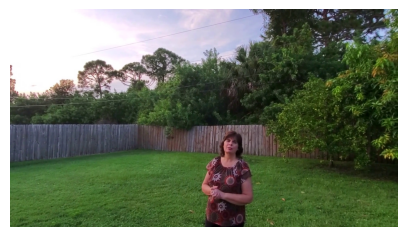

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(frame_list[0])
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [1]:
!pip install "numpy<2.0.0"

In [ ]:
import numpy
print(f"현재 넘파이 버전: {numpy.__version__}")
# 결과가 1.26.4 같은 식으로 나오면 이제 무적입니다!

In [2]:
import numpy as np
import torch
import facenet_pytorch

print(f"✅ 넘파이 버전: {np.__version__}") # 1.26.4가 나오면 성공!
print(f"✅ 가위 준비 완료: {facenet_pytorch.__name__}")

# 이제 아까 드린 '얼굴 추출 코드 (MTCNN 포함)' 셀을 바로 실행하세요!

✅ 넘파이 버전: 1.26.4
✅ 가위 준비 완료: facenet_pytorch


In [7]:
!pip install mediapipe

In [15]:
import os
import cv2
import glob
import numpy as np

input_root = "frames_face"
output_root = "roi_frames"
os.makedirs(output_root, exist_ok=True)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

frame_files = glob.glob(os.path.join(input_root, "*", "*", "*.jpg"))
print("전체 프레임 수:", len(frame_files))

count_ok = 0
count_fail = 0

for frame_path in frame_files:
    img = cv2.imread(frame_path)
    if img is None:
        count_fail += 1
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(50, 50)
    )

    if len(faces) == 0:
        count_fail += 1
        continue

    # 가장 큰 얼굴 선택
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    face_crop = img[y:y+h, x:x+w]
    fh, fw = face_crop.shape[:2]

    # 마스크 생성
    mask = np.zeros((fh, fw), dtype=np.uint8)

    # 1) 얼굴 외곽 경계면: 타원형 얼굴 마스크 - 안쪽 타원
    center = (fw // 2, fh // 2)
    axes_outer = (int(fw * 0.48), int(fh * 0.48))
    axes_inner = (int(fw * 0.38), int(fh * 0.38))

    outer = np.zeros((fh, fw), dtype=np.uint8)
    inner = np.zeros((fh, fw), dtype=np.uint8)

    cv2.ellipse(outer, center, axes_outer, 0, 0, 360, 255, -1)
    cv2.ellipse(inner, center, axes_inner, 0, 0, 360, 255, -1)

    boundary_ring = cv2.subtract(outer, inner)

    # 2) 입 주변부: 얼굴 비율 기준 입 위치 추정
    mouth_x1 = int(fw * 0.30)
    mouth_x2 = int(fw * 0.70)
    mouth_y1 = int(fh * 0.62)
    mouth_y2 = int(fh * 0.82)

    mouth_mask = np.zeros((fh, fw), dtype=np.uint8)
    cv2.rectangle(mouth_mask, (mouth_x1, mouth_y1), (mouth_x2, mouth_y2), 255, -1)

    # 입 내부 깎아서 주변부만 남기기
    mouth_inner = np.zeros((fh, fw), dtype=np.uint8)
    cv2.rectangle(
        mouth_inner,
        (int(fw * 0.36), int(fh * 0.67)),
        (int(fw * 0.64), int(fh * 0.77)),
        255,
        -1
    )

    mouth_ring = cv2.subtract(mouth_mask, mouth_inner)

    # 최종 마스크 = 얼굴 경계면 + 입 주변부
    final_mask = cv2.bitwise_or(boundary_ring, mouth_ring)

    # 마스크 적용
    roi_img = cv2.bitwise_and(face_crop, face_crop, mask=final_mask)

    # 너무 비어 있으면 실패 처리
    if np.count_nonzero(final_mask) < 500:
        count_fail += 1
        continue

    roi_img = cv2.resize(roi_img, (224, 224))

    rel_path = os.path.relpath(frame_path, input_root)
    save_path = os.path.join(output_root, rel_path)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    cv2.imwrite(save_path, roi_img)
    count_ok += 1

print("성공:", count_ok)
print("실패:", count_fail)

전체 프레임 수: 488
성공: 99
실패: 389


In [18]:
import os
import cv2
import glob
import numpy as np
import shutil

# --- 1. 경로 설정 (반드시 'frames_face'로 고정!) ---
input_root = "frames_face"  # <- 얼굴만 들어있는 그 폴더!
output_root = "roi_frames"

# 꼬임을 방지하기 위해 기존 ROI 폴더를 아예 지우고 새로 만듭니다
if os.path.exists(output_root):
    shutil.rmtree(output_root)
os.makedirs(output_root, exist_ok=True)

# --- 2. 얼굴 검출기 설정 ---
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# --- 3. 파일 목록 가져오기 ---
# frames_face/라벨/영상명/*.jpg 구조를 정확히 훑습니다
frame_files = glob.glob(os.path.join(input_root, "**", "*.jpg"), recursive=True)
print(f"✅ 분석할 얼굴 이미지 개수: {len(frame_files)}")

if len(frame_files) == 0:
    print("❌ 에러: 'frames_face' 폴더가 비어있거나 경로가 틀렸습니다!")
else:
    count_ok = 0
    count_fail = 0

    for frame_path in frame_files:
        img = cv2.imread(frame_path)
        if img is None:
            count_fail += 1
            continue

        # 회색조 변환 및 얼굴 재검출 (잘라낸 사진 안에서 다시 한번 위치 확인)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 3, minSize=(50, 50))

        if len(faces) == 0:
            # 잘라낸 사진인데도 검출 안 되면 이미지 전체를 얼굴로 간주 (이미 얼굴만 뽑은 거니까요!)
            fh, fw = img.shape[:2]
            face_crop = img
        else:
            # 가장 큰 얼굴 선택해서 크롭
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
            face_crop = img[y:y+h, x:x+w]
            fh, fw = face_crop.shape[:2]

        # --- 4. 마스크 조각하기 (기존과 동일) ---
        mask = np.zeros((fh, fw), dtype=np.uint8)
        center = (fw // 2, fh // 2)
        axes_outer = (int(fw * 0.48), int(fh * 0.48))
        axes_inner = (int(fw * 0.38), int(fh * 0.38))

        outer = np.zeros((fh, fw), dtype=np.uint8)
        inner = np.zeros((fh, fw), dtype=np.uint8)
        cv2.ellipse(outer, center, axes_outer, 0, 0, 360, 255, -1)
        cv2.ellipse(inner, center, axes_inner, 0, 0, 360, 255, -1)
        boundary_ring = cv2.subtract(outer, inner)

        # 입 주변부
        mouth_mask = np.zeros((fh, fw), dtype=np.uint8)
        cv2.rectangle(mouth_mask, (int(fw*0.3), int(fh*0.62)), (int(fw*0.7), int(fh*0.82)), 255, -1)
        final_mask = cv2.bitwise_or(boundary_ring, mouth_mask)

        # 마스크 적용
        roi_img = cv2.bitwise_and(face_crop, face_crop, mask=final_mask)
        roi_img = cv2.resize(roi_img, (224, 224))

        # --- 5. 저장 (경로 구조 유지) ---
        rel_path = os.path.relpath(frame_path, input_root)
        save_path = os.path.join(output_root, rel_path)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        cv2.imwrite(save_path, roi_img)
        count_ok += 1

    print(f"\n✨ 완료! 성공: {count_ok} / 실패: {count_fail}")

✅ 분석할 얼굴 이미지 개수: 488

✨ 완료! 성공: 488 / 실패: 0


ROI 이미지 수: 488
예시: ['roi_frames/REAL/puudvugxrl/frame_9.jpg', 'roi_frames/REAL/puudvugxrl/frame_2.jpg', 'roi_frames/REAL/puudvugxrl/frame_4.jpg', 'roi_frames/REAL/puudvugxrl/frame_0.jpg', 'roi_frames/REAL/puudvugxrl/frame_7.jpg']


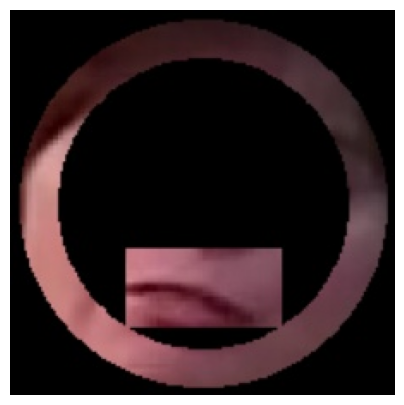

In [19]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

roi_list = glob.glob("roi_frames/*/*/*.jpg")
print("ROI 이미지 수:", len(roi_list))
print("예시:", roi_list[:5])

img = Image.open(roi_list[0])
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
!rm -rf dataset_split

In [21]:
import os
import glob
import random
import shutil

random.seed(42)

src_root = "roi_frames"
dst_root = "dataset_split"
classes = ["REAL", "FAKE"]
split_ratio = 0.8

for cls in classes:
    files = glob.glob(os.path.join(src_root, cls, "*", "*.jpg"))
    print(f"{cls} 원본 개수:", len(files))

    random.shuffle(files)
    split_idx = int(len(files) * split_ratio)

    train_files = files[:split_idx]
    val_files = files[split_idx:]

    for split_name, split_files in [("train", train_files), ("val", val_files)]:
        save_dir = os.path.join(dst_root, split_name, cls)
        os.makedirs(save_dir, exist_ok=True)

        for i, file_path in enumerate(split_files):
            new_name = f"{cls.lower()}_{i:05d}.jpg"
            shutil.copy(file_path, os.path.join(save_dir, new_name))

        print(f"{split_name}/{cls}:", len(split_files))

print("분할 완료")

REAL 원본 개수: 20
train/REAL: 16
val/REAL: 4
FAKE 원본 개수: 468
train/FAKE: 374
val/FAKE: 94
분할 완료


In [22]:
!find dataset_split/train/REAL -type f | wc -l
!find dataset_split/train/FAKE -type f | wc -l
!find dataset_split/val/REAL -type f | wc -l
!find dataset_split/val/FAKE -type f | wc -l

16
374
4
94


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("dataset_split/train", transform=transform)
val_dataset = datasets.ImageFolder("dataset_split/val", transform=transform)

print("클래스:", train_dataset.classes)
print("train 개수:", len(train_dataset))
print("val 개수:", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

device: cpu
클래스: ['FAKE', 'REAL']
train 개수: 390
val 개수: 98


In [24]:
num_epochs = 5
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18_roi.pth")
        print("best 모델 저장 완료")

Epoch 1/5 | Train Loss: 0.2662 | Train Acc: 0.8974 | Val Loss: 0.5471 | Val Acc: 0.9592
best 모델 저장 완료
Epoch 2/5 | Train Loss: 0.0525 | Train Acc: 0.9897 | Val Loss: 0.0961 | Val Acc: 0.9796
best 모델 저장 완료
Epoch 3/5 | Train Loss: 0.0165 | Train Acc: 0.9974 | Val Loss: 0.1070 | Val Acc: 0.9796
Epoch 4/5 | Train Loss: 0.0079 | Train Acc: 1.0000 | Val Loss: 0.1905 | Val Acc: 0.9796
Epoch 5/5 | Train Loss: 0.0054 | Train Acc: 1.0000 | Val Loss: 0.1403 | Val Acc: 0.9796


In [25]:
torch.save(model.state_dict(), "last_resnet18_roi.pth")
print("마지막 모델 저장 완료")
print("최고 검증 정확도:", best_val_acc)

마지막 모델 저장 완료
최고 검증 정확도: 0.9795918367346939


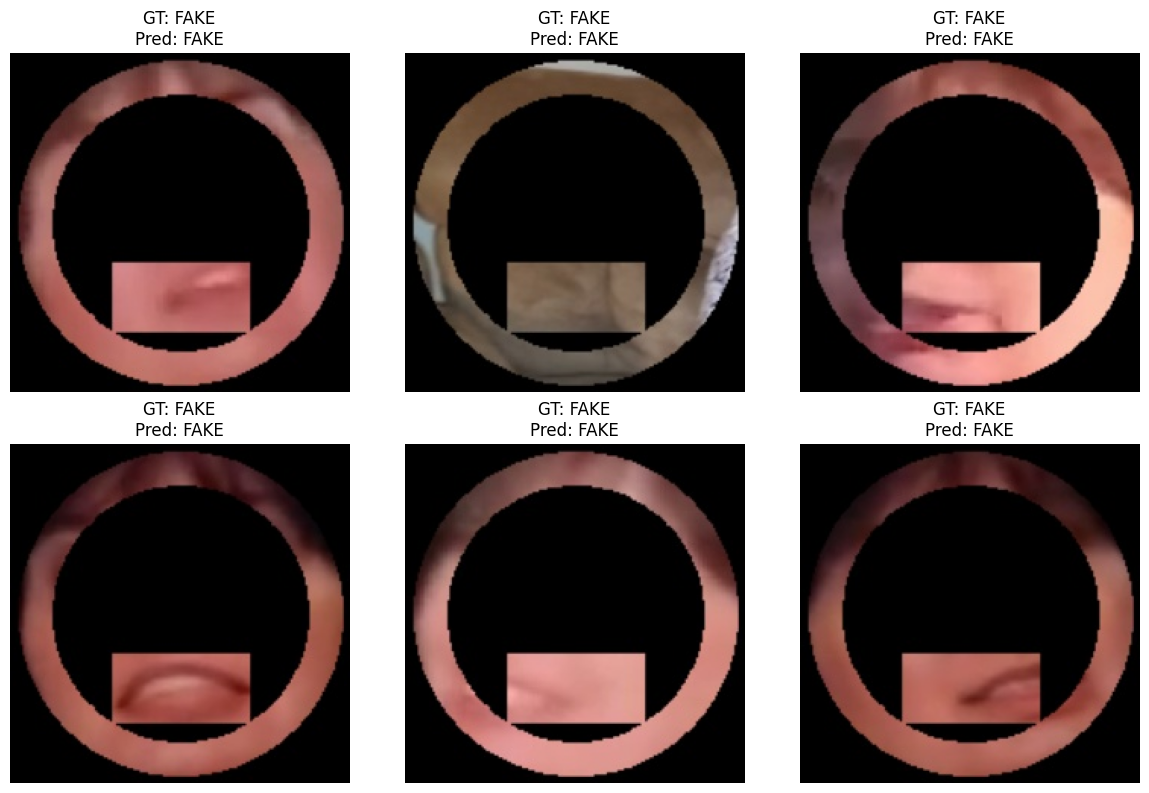

In [26]:
import matplotlib.pyplot as plt
import numpy as np

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

model.load_state_dict(torch.load("best_resnet18_roi.pth"))
model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

plt.figure(figsize=(12, 8))
for i in range(min(6, len(images_cpu))):
    img = images_cpu[i].permute(1, 2, 0).numpy()
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"GT: {idx_to_class[labels_cpu[i].item()]}\nPred: {idx_to_class[preds_cpu[i].item()]}")
    plt.axis("off")
plt.tight_layout()
plt.show()